# PROJECT THAT CONSISTS IN SAVING AND LOADING MODELS WITH APPLICATION TO THE EUROSAT DATASET

the idea is create a neural network that classifies and land uses and land covers from satellite imagery. 

!['Imagen'](data/eurosat_overview.jpg)

### Import Libraries


In [1]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import numpy as np
import pandas as pd

#
import matplotlib.pyplot as plt



!['Imagen'](data/eurosat_overview.jpg)

[EuroSAT dataset](https://github.com/phelber/EuroSAT). It consists of 27000 labelled Sentinel-2 satellite images of different land uses: residential, industrial, highway, river, forest, pasture, herbaceous vegetation, annual crop, permanent crop and sea/lake. For a reference, see the following papers:
- Eurosat: A novel dataset and deep learning benchmark for land use and land cover classification. Patrick Helber, Benjamin Bischke, Andreas Dengel, Damian Borth. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 2019.
- Introducing EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification. Patrick Helber, Benjamin Bischke, Andreas Dengel. 2018 IEEE International Geoscience and Remote Sensing Symposium, 2018.

The goal is to construct a neural network that classifies a satellite image into one of these 10 classes, as well as applying some of the saving and loading techniques you have learned in the previous sessions.

### Import the Data

In [2]:

def load_eurosat_data():
    data_dir = 'data/'
    x_train = np.load(os.path.join(data_dir, 'x_train.npy'))
    y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
    x_test = np.load(os.path.join(data_dir, 'x_test.npy'))
    y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

    return (x_train, y_train), (x_test, y_test)

(x_train, y_train),(x_test, y_test) = load_eurosat_data()

x_train = x_train/ 255.0
x_test = x_test/ 255.0   

print(f'Shape of Training set {x_train.shape}')
print(f'Shape of Test set {x_test.shape}')


Shape of Training set (4000, 64, 64, 3)
Shape of Test set (1000, 64, 64, 3)


### Looking some Images

In [3]:
labels = {
    0: 'AnnualCrop',
    1: 'Forest',
    2: 'HerbaceousVegetation',
    3: 'Highway',
    4: 'Industrial',
    5: 'Pasture',
    6: 'PermanentCrop',
    7: 'Residential',
    8: 'River',
    9: 'SeaLake'
}


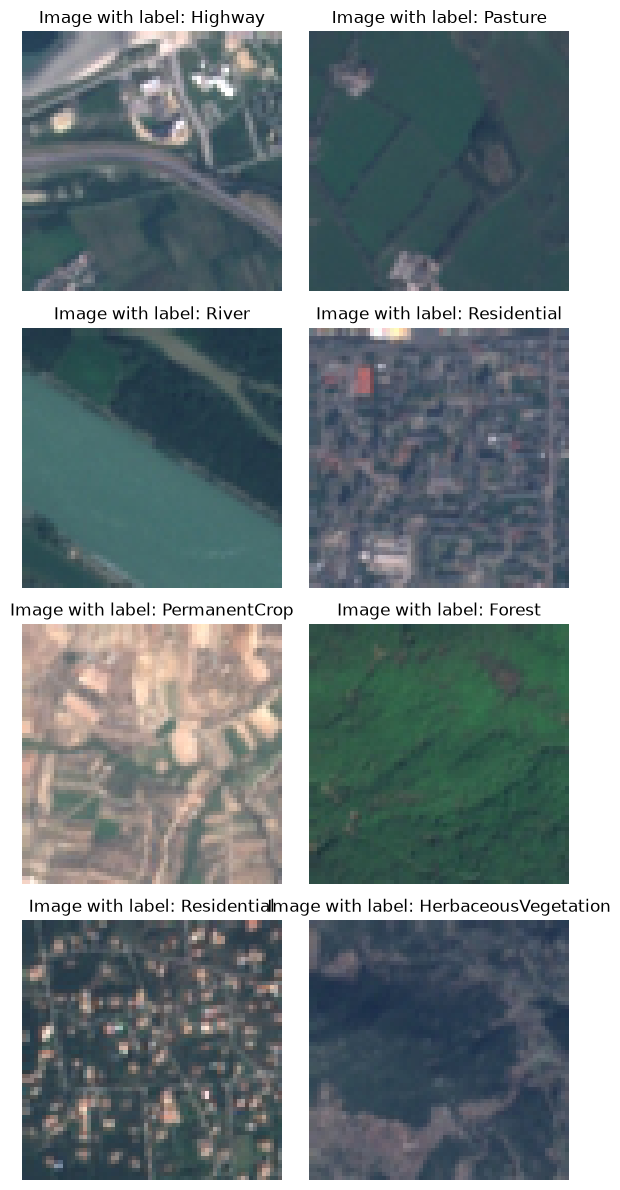

In [4]:

idx = np.random.choice(x_train.shape[0], size=8, replace=True)


fig, axes = plt.subplots(4,2, figsize=(6,12))

for i, ax in enumerate(axes.flat):
    image = x_train[idx[i]]

    num_label = int(y_train[idx[i]].item())
    ax.imshow(image)
    ax.set_title(f"Image with label: {labels[num_label]}")
    ax.axis("off")  
plt.tight_layout()
plt.show()



## Building the Neural Network Model

In [5]:
def get_new_model(input_shape):
    model = Sequential([
        Conv2D(16, (3,3), input_shape=input_shape, padding='same',
               activation='relu', name='conv_1'),
        Conv2D(8, (3,3),  padding='same',
                       activation='relu', name='conv_2'),
        MaxPooling2D((8,8), name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu', name='dense_1'),
        Dense(10, activation='softmax', name='dense_2')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


    return model


In [6]:
model = get_new_model(x_train[0].shape)

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:

def get_test_accuracy(model, x_test, y_test):

    test_loss, test_acc = model.evaluate(x=x_test, y=y_test, verbose=0)
    print(f"Accuracy: {test_acc:.4f}")

In [14]:
model.summary()
get_test_accuracy(model, x_test, y_test)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 64, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,354 (71.70 KB)

 Trainable params: 18,354 (71.70 KB)

 Non-trainable params: 0 (0.00 B)

Accuracy: 0.1120


This accuracy meassure shows the low accuracy when we use the model in test with the initializer weights. 

### Callbacks to every epoch

In [ ]:
def get_checkpoint_every_epoch():


    path = "checkpoints_every_epoch/checkpoint_{epoch:03d}.weights.h5"

    checkpoint_every = ModelCheckpoint(save_weights_only=True, filepath=path,
                                       save_freq='epoch',verbose=1)

    return checkpoint_every


### Callback to best only

In [17]:
def get_checkpoint_best_only():

    path = "checkpoints_best_only/checkpoint.weights.h5"

    checkpoint_best = ModelCheckpoint(save_weights_only=True,
                                      save_best_only=True, filepath=path,
                                      monitor='val_accuracy', mode='max',
                                      verbose=1)

    return checkpoint_best

### Callback to Early Stopping

In [18]:

def get_early_stopping():

    early_stopping = EarlyStopping(monitor='val_accuracy',
                                   patience=3)

    return early_stopping


### Creating the Callbacks

In [19]:
checkpoint_every_epoch = get_checkpoint_every_epoch()
checkpoint_best_only = get_checkpoint_best_only()
early_stopping = get_early_stopping()

## Training the model using the callbacks

In [20]:

callbacks = [checkpoint_every_epoch, checkpoint_best_only, early_stopping]

model.fit(x_train, y_train, epochs=50,
          validation_data=(x_test, y_test),
          callbacks=callbacks, verbose=2)


Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.29700, saving model to checkpoints_best_only/checkpoint.weights.h5

Epoch 1: finished saving model to checkpoints_best_only/checkpoint.weights.h5
125/125 - 1s - 12ms/step - accuracy: 0.2380 - loss: 1.9987 - val_accuracy: 0.2970 - val_loss: 1.7397
Epoch 2/50

Epoch 2: val_accuracy improved from 0.29700 to 0.36500, saving model to checkpoints_best_only/checkpoint.weights.h5

Epoch 2: finished saving model to checkpoints_best_only/checkpoint.weights.h5
125/125 - 1s - 5ms/step - accuracy: 0.3865 - loss: 1.5927 - val_accuracy: 0.3650 - val_loss: 1.5374
Epoch 3/50

Epoch 3: val_accuracy improved from 0.36500 to 0.41300, saving model to checkpoints_best_only/checkpoint.weights.h5

Epoch 3: finished saving model to checkpoints_best_only/checkpoint.weights.h5
125/125 - 1s - 5ms/step - accuracy: 0.4462 - loss: 1.4312 - val_accuracy: 0.4130 - val_loss: 1.4682
Epoch 4/50

Epoch 4: val_accuracy improved from 0.41300 to 0.47700, saving model 

## Creating a new instance of model and load on both sets of weights